In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import numpy as np
import json
import matplotlib.pyplot as plt
import random
import seaborn as sns
from collections import Counter

sns.set(style="whitegrid")


In [3]:
BASE_PATH = "/content/drive/MyDrive/nsynth_proccessed_dataset/train"

X = np.load(f"{BASE_PATH}/X.npy")
y = np.load(f"{BASE_PATH}/y.npy")

with open("/content/drive/MyDrive/nsynth_proccessed_dataset/class_mapping.json", "r") as f:
    class_mapping = json.load(f)

# Reverse mapping: id → class name
id_to_class = {v: k for k, v in class_mapping.items()}

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Number of classes:", len(id_to_class))


X shape: (12000, 128, 128)
y shape: (12000,)
Number of classes: 8


/tmp/ipython-input-9167922.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=counts, palette="viridis")


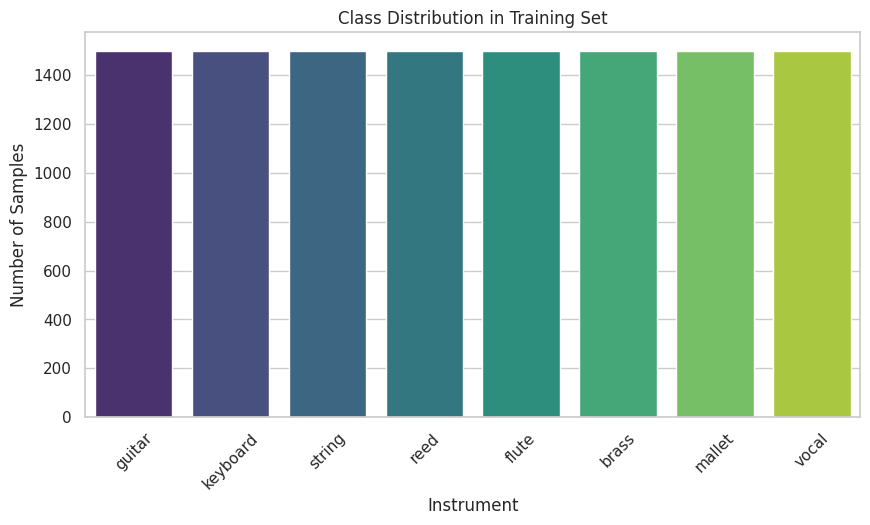

In [4]:
class_counts = Counter(y)

labels = [id_to_class[i] for i in class_counts.keys()]
counts = list(class_counts.values())

plt.figure(figsize=(10, 5))
sns.barplot(x=labels, y=counts, palette="viridis")
plt.title("Class Distribution in Training Set")
plt.ylabel("Number of Samples")
plt.xlabel("Instrument")
plt.xticks(rotation=45)
plt.show()


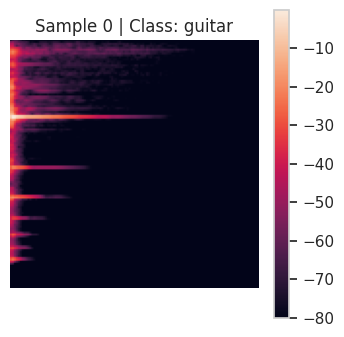

In [5]:
plt.figure(figsize=(4, 4))
plt.imshow(X[0])
plt.colorbar()
plt.title(f"Sample 0 | Class: {id_to_class[y[0]]}")
plt.axis("off")
plt.show()


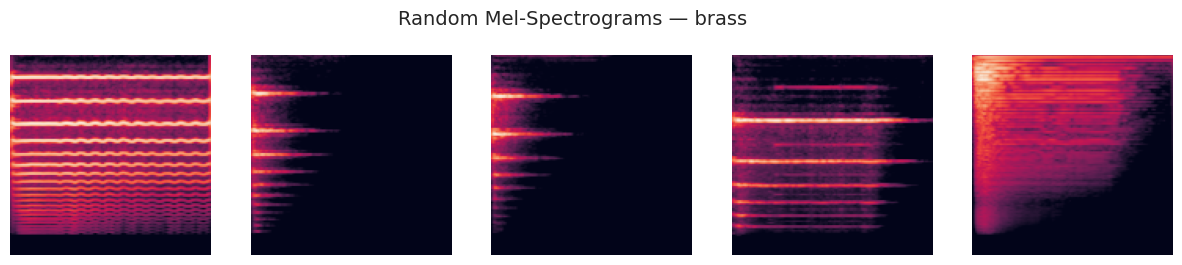

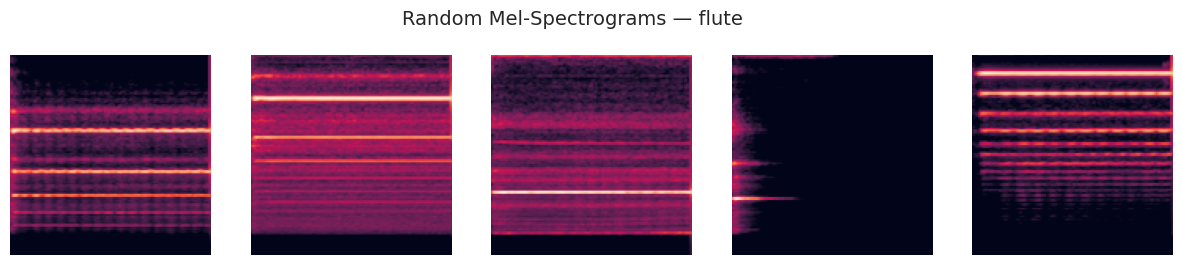

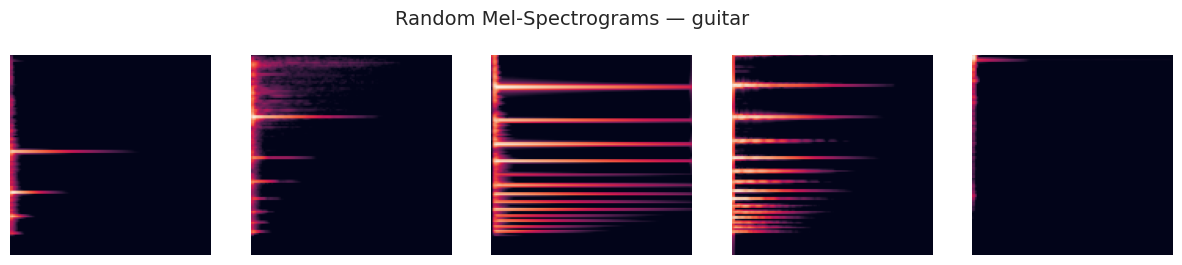

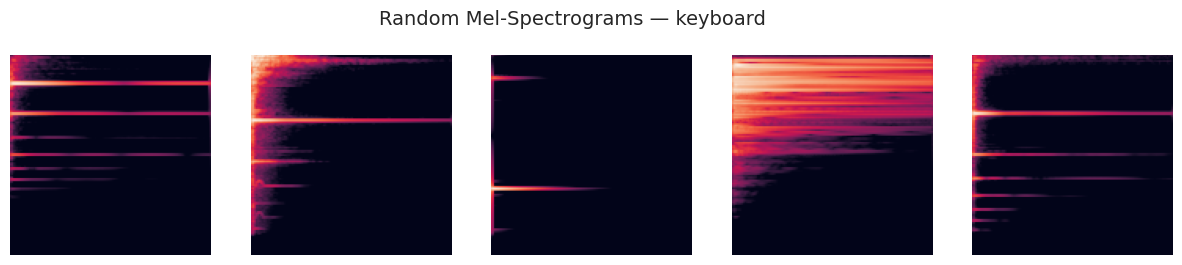

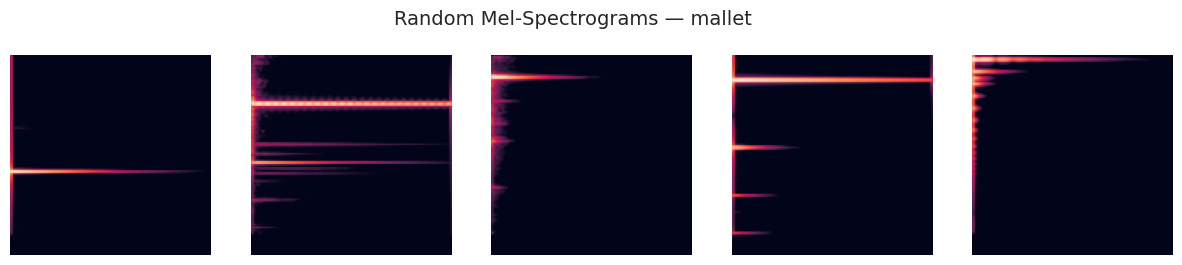

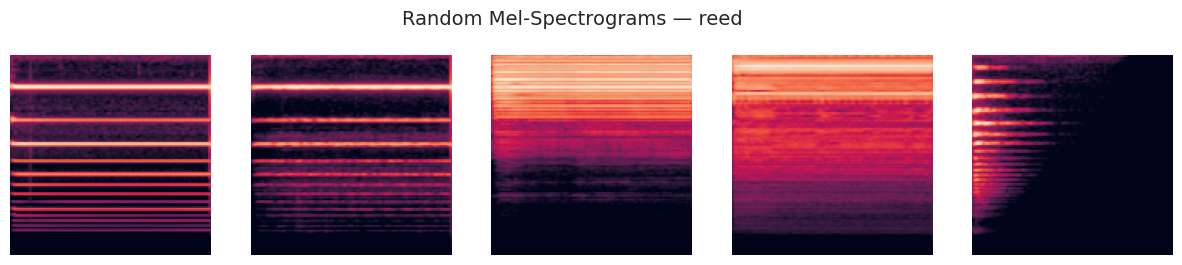

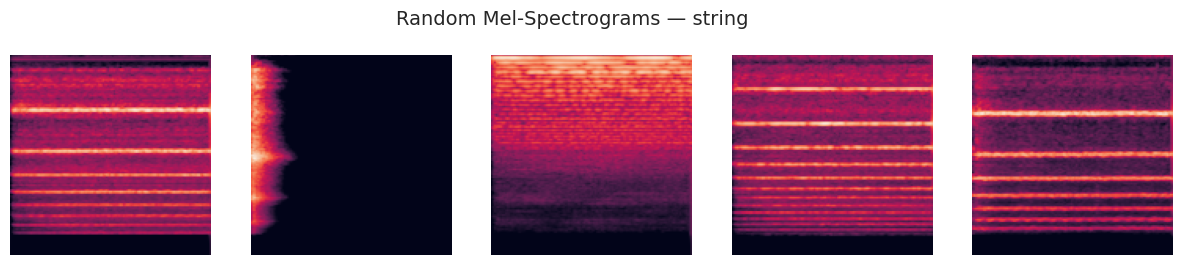

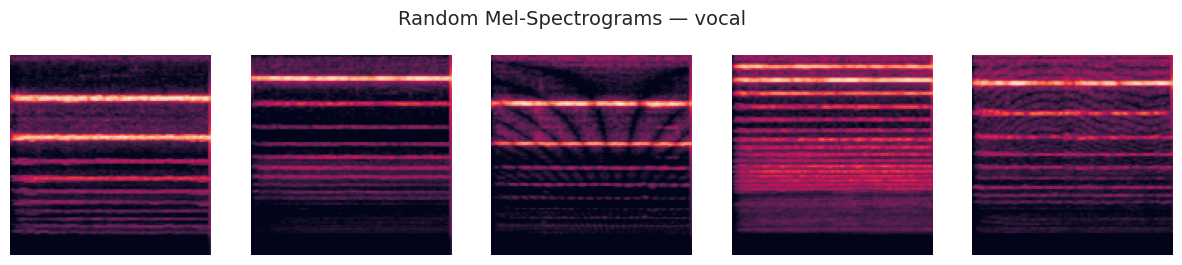

In [6]:
NUM_SAMPLES = 5

for class_id, class_name in id_to_class.items():
    indices = np.where(y == class_id)[0]

    if len(indices) == 0:
        continue

    chosen = random.sample(list(indices), min(NUM_SAMPLES, len(indices)))

    plt.figure(figsize=(15, 3))
    for i, idx in enumerate(chosen):
        plt.subplot(1, NUM_SAMPLES, i + 1)
        plt.imshow(X[idx])
        plt.axis("off")

    plt.suptitle(f"Random Mel-Spectrograms — {class_name}", fontsize=14)
    plt.show()


In [7]:
print("Global statistics:")
print("Min value:", X.min())
print("Max value:", X.max())
print("Mean value:", X.mean())
print("Std deviation:", X.std())


Global statistics:
Min value: -80.0
Max value: -2.682209e-07
Mean value: -65.285095
Std deviation: 18.99223


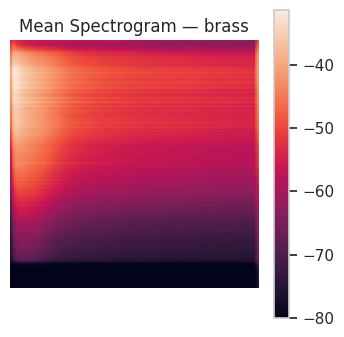

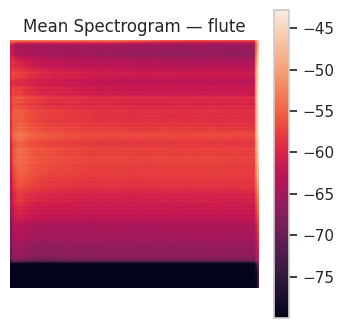

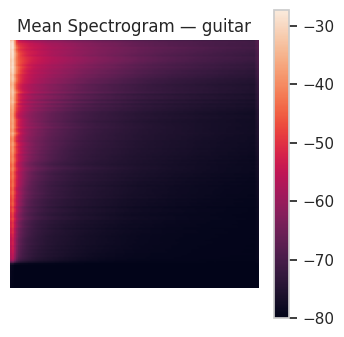

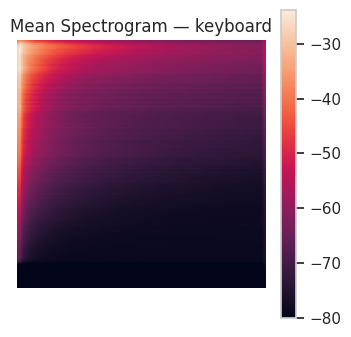

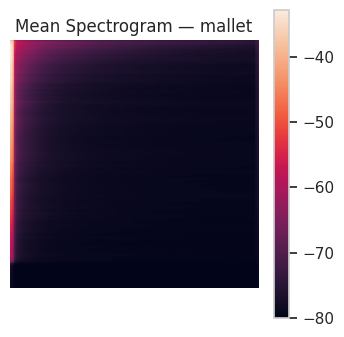

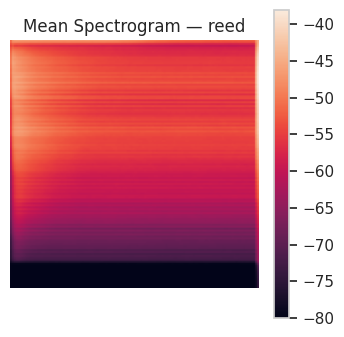

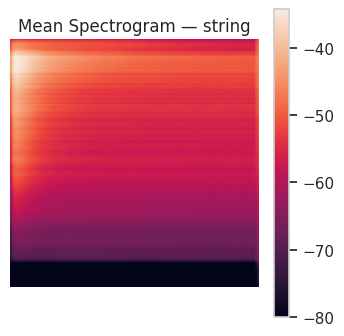

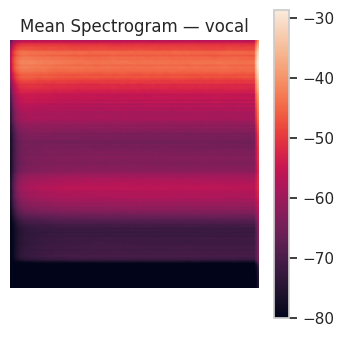

In [8]:
for class_id, class_name in id_to_class.items():
    class_indices = np.where(y == class_id)[0]
    if len(class_indices) == 0:
        continue

    mean_spec = np.mean(X[class_indices], axis=0)

    plt.figure(figsize=(4, 4))
    plt.imshow(mean_spec)
    plt.title(f"Mean Spectrogram — {class_name}")
    plt.colorbar()
    plt.axis("off")
    plt.show()


# Milestone - 2

In [9]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, GlobalAveragePooling2D,
    Dense, Dropout, BatchNormalization
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import classification_report, confusion_matrix

sns.set(style="whitegrid")


In [11]:
BASE_PATH = "/content/drive/MyDrive/nsynth_proccessed_dataset"

X_train = np.load(f"{BASE_PATH}/train/X.npy")
y_train = np.load(f"{BASE_PATH}/train/y.npy")

X_valid = np.load(f"{BASE_PATH}/valid/X.npy")
y_valid = np.load(f"{BASE_PATH}/valid/y.npy")

X_test  = np.load(f"{BASE_PATH}/test/X.npy")
y_test  = np.load(f"{BASE_PATH}/test/y.npy")

with open(f"{BASE_PATH}/class_mapping.json") as f:
    class_mapping = json.load(f)

id_to_class = {v: k for k, v in class_mapping.items()}

print("Train:", X_train.shape, y_train.shape)
print("Valid:", X_valid.shape, y_valid.shape)
print("Test :", X_test.shape, y_test.shape)


Train: (12000, 128, 128) (12000,)
Valid: (5124, 128, 128) (5124,)
Test : (1689, 128, 128) (1689,)


In [12]:
# Add channel dimension: (128,128) → (128,128,1)
X_train = X_train[..., np.newaxis]
X_valid = X_valid[..., np.newaxis]
X_test  = X_test[..., np.newaxis]

# Normalize to [0,1]
X_train = (X_train - X_train.min()) / (X_train.max() - X_train.min())
X_valid = (X_valid - X_valid.min()) / (X_valid.max() - X_valid.min())
X_test  = (X_test - X_test.min())  / (X_test.max()  - X_test.min())

# One-hot encode labels
NUM_CLASSES = len(class_mapping)
y_train_cat = to_categorical(y_train, NUM_CLASSES)
y_valid_cat = to_categorical(y_valid, NUM_CLASSES)
y_test_cat  = to_categorical(y_test,  NUM_CLASSES)

print("Final input shape:", X_train.shape)


Final input shape: (12000, 128, 128, 1)


In [13]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

# y_train is integer labels (0–7)
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))

print("Class Weights:")
for k, v in class_weights.items():
    print(f"Class {k}: {v:.3f}")


Class Weights:
Class 0: 1.000
Class 1: 1.000
Class 2: 1.000
Class 3: 1.000
Class 4: 1.000
Class 5: 1.000
Class 6: 1.000
Class 7: 1.000


In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D,
    BatchNormalization,
    GlobalAveragePooling2D,
    Dense, Dropout
)

model = Sequential([
    Conv2D(32, (3,3), padding="same", activation="relu", input_shape=(128,128,1)),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), padding="same", activation="relu"),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(128, (3,3), padding="same", activation="relu"),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    GlobalAveragePooling2D(),

    Dense(128, activation="relu"),
    Dropout(0.3),

    Dense(NUM_CLASSES, activation="softmax")
])

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,112 (434.03 KB)

 Trainable params: 110,664 (432.28 KB)

 Non-trainable params: 448 (1.75 KB)

In [15]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import CategoricalCrossentropy

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy"]
)


In [16]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

callbacks = [
    ModelCheckpoint(
        "/content/drive/MyDrive/best_instrunet_model_v2.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    ),

    EarlyStopping(
        monitor="val_loss",
        patience=7,           # ⬅ increased
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=5,
        min_lr=1e-6,
        verbose=1
    )
]


In [ ]:
history = model.fit(
    X_train, y_train_cat,
    validation_data=(X_valid, y_valid_cat),
    epochs=30,
    batch_size=32,
    callbacks=callbacks,
    class_weight=class_weights
)


NameError: name 'history' is not defined

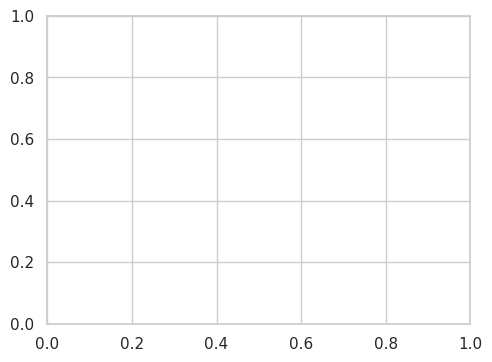

In [17]:
plt.figure(figsize=(12,4))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Valid")
plt.title("Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Valid")
plt.title("Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()


In [21]:
from tensorflow.keras.models import load_model

best_model_path = "/content/drive/MyDrive/best_instrunet_model_v2.keras"

best_model = load_model(best_model_path)


In [22]:
test_loss, test_acc = best_model.evaluate(X_test, y_test_cat, verbose=1)

print(f"✅ Test Loss     : {test_loss:.4f}")
print(f"✅ Test Accuracy : {test_acc:.4f}")


53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.8572 - loss: 0.9212
✅ Test Loss     : 0.9113
✅ Test Accuracy : 0.8615


In [23]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# Predict probabilities
y_pred_probs = best_model.predict(X_test)

# Convert to class indices
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test_cat, axis=1)

print(classification_report(
    y_true,
    y_pred,
    target_names=[id_to_class[i] for i in range(NUM_CLASSES)]
))


53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step
              precision    recall  f1-score   support

       brass       0.77      0.93      0.84       269
       flute       0.89      1.00      0.94        55
      guitar       0.97      0.78      0.86       481
    keyboard       0.83      0.98      0.90       119
      mallet       0.68      0.90      0.77       202
        reed       0.87      0.65      0.75       235
      string       0.98      0.99      0.98       306
       vocal       1.00      1.00      1.00        22

    accuracy                           0.86      1689
   macro avg       0.87      0.90      0.88      1689
weighted avg       0.88      0.86      0.86      1689



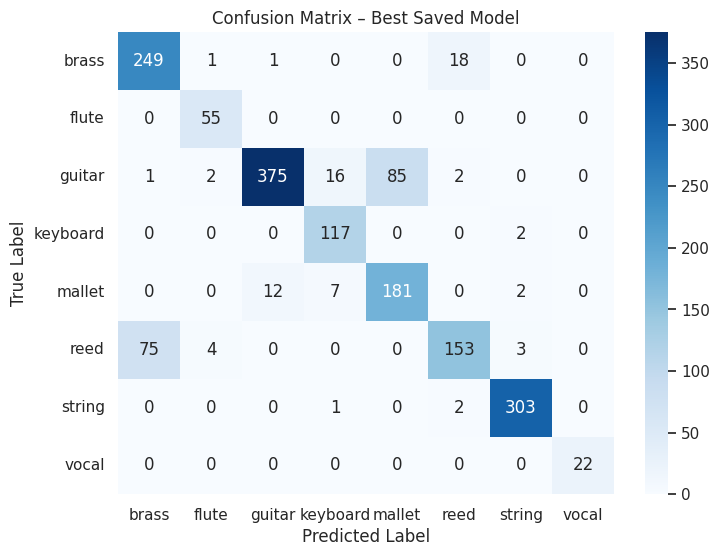

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[id_to_class[i] for i in range(NUM_CLASSES)],
    yticklabels=[id_to_class[i] for i in range(NUM_CLASSES)]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix – Best Saved Model")
plt.show()


In [25]:
model.save("/content/drive/MyDrive/nsynth_proccessed_dataset/instrunet_cnn_model(baseline2).keras")
print("✅ Model saved successfully")


✅ Model saved successfully


# MileStone 3

In [26]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D, MaxPooling2D,
    BatchNormalization,
    GlobalAveragePooling2D,
    Dense, Dropout
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)
from sklearn.utils.class_weight import compute_class_weight


In [27]:
# y_train should be integer encoded labels (0–7)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))

print("Class weights:", class_weights)


Class weights: {0: np.float64(1.0), 1: np.float64(1.0), 2: np.float64(1.0), 3: np.float64(1.0), 4: np.float64(1.0), 5: np.float64(1.0), 6: np.float64(1.0), 7: np.float64(1.0)}


In [28]:
NUM_CLASSES = 8

model = Sequential([
    # ---------------- INPUT ----------------
    Input(shape=(128, 128, 1)),

    # ---------------- BLOCK 0 (Transient capture) ----------------
    Conv2D(16, (3, 3), padding="same", activation="relu"),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    # ---------------- BLOCK 1 ----------------
    Conv2D(32, (3, 3), padding="same", activation="relu"),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    # ---------------- BLOCK 2 ----------------
    Conv2D(64, (3, 3), padding="same", activation="relu"),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    # ---------------- BLOCK 3 (Frequency-aware) ----------------
    Conv2D(128, (5, 3), padding="same", activation="relu"),
    BatchNormalization(),

    # ---------------- BLOCK 4 (Time-aware) ----------------
    Conv2D(256, (3, 5), padding="same", activation="relu"),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    # ---------------- GLOBAL POOLING ----------------
    GlobalAveragePooling2D(),

    # ---------------- DENSE HEAD ----------------
    Dense(128, activation="relu"),
    Dropout(0.3),

    Dense(NUM_CLASSES, activation="softmax")
])

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 16)   │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128, 128, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 128)    │       123,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 256)    │       491,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 673,992 (2.57 MB)

 Trainable params: 673,000 (2.57 MB)

 Non-trainable params: 992 (3.88 KB)

In [32]:
optimizer = Adam(
    learning_rate=0.0007,
    clipnorm=1.0
)

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)



In [33]:
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=4,
        min_lr=1e-5,
        verbose=1
    ),

    ModelCheckpoint(
        filepath="/content/drive/MyDrive/best_instrunet_model_v3.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    )
]


In [34]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_valid, y_valid),
    epochs=50,
    batch_size=32,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/50
373/375 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5258 - loss: 1.3293
Epoch 1: val_accuracy improved from -inf to 0.14696, saving model to /content/drive/MyDrive/best_instrunet_model_v3.keras
375/375 ━━━━━━━━━━━━━━━━━━━━ 19s 29ms/step - accuracy: 0.5268 - loss: 1.3266 - val_accuracy: 0.1470 - val_loss: 3.2308 - learning_rate: 0.0010
Epoch 2/50
373/375 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8014 - loss: 0.5517
Epoch 2: val_accuracy improved from 0.14696 to 0.58060, saving model to /content/drive/MyDrive/best_instrunet_model_v3.keras
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.8015 - loss: 0.5513 - val_accuracy: 0.5806 - val_loss: 1.7333 - learning_rate: 0.0010
Epoch 3/50
373/375 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8745 - loss: 0.3547
Epoch 3: val_accuracy improved from 0.58060 to 0.64715, saving model to /content/drive/MyDrive/best_instrunet_model_v3.keras
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.8745 - loss: 0.3546 - val_

In [35]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=1)
print(f"Test Accuracy: {test_acc:.4f}")


53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.8703 - loss: 0.6650
Test Accuracy: 0.8709


53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step
              precision    recall  f1-score   support

       brass       0.83      0.93      0.88       269
       flute       0.92      1.00      0.96        55
      guitar       0.93      0.80      0.86       481
    keyboard       0.86      0.95      0.90       119
      mallet       0.75      0.92      0.82       202
        reed       0.93      0.68      0.79       235
      string       0.88      0.99      0.93       306
       vocal       1.00      1.00      1.00        22

    accuracy                           0.87      1689
   macro avg       0.89      0.91      0.89      1689
weighted avg       0.88      0.87      0.87      1689



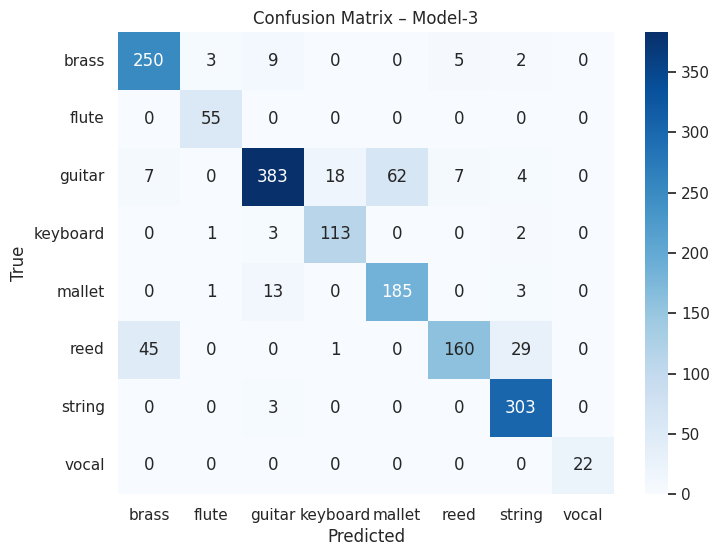

In [36]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

print(classification_report(
    y_test,
    y_pred,
    target_names=[id_to_class[i] for i in range(NUM_CLASSES)]
))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[id_to_class[i] for i in range(NUM_CLASSES)],
    yticklabels=[id_to_class[i] for i in range(NUM_CLASSES)]
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix – Model-3")
plt.show()


In [63]:
import tensorflow as tf

MODEL_PATH = "/content/drive/MyDrive/best_instrunet_model_v3.keras"

model = tf.keras.models.load_model(MODEL_PATH)
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 16)   │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128, 128, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 128)    │       123,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 256)    │       491,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,019,994 (7.71 MB)

 Trainable params: 673,000 (2.57 MB)

 Non-trainable params: 992 (3.88 KB)

 Optimizer params: 1,346,002 (5.13 MB)

In [64]:
id_to_class = {
    0: "brass",
    1: "flute",
    2: "guitar",
    3: "keyboard",
    4: "mallet",
    5: "reed",
    6: "string",
    7: "vocal"
}


In [65]:
import numpy as np
import random

NUM_SAMPLES = 5

indices = random.sample(range(len(X_test)), NUM_SAMPLES)


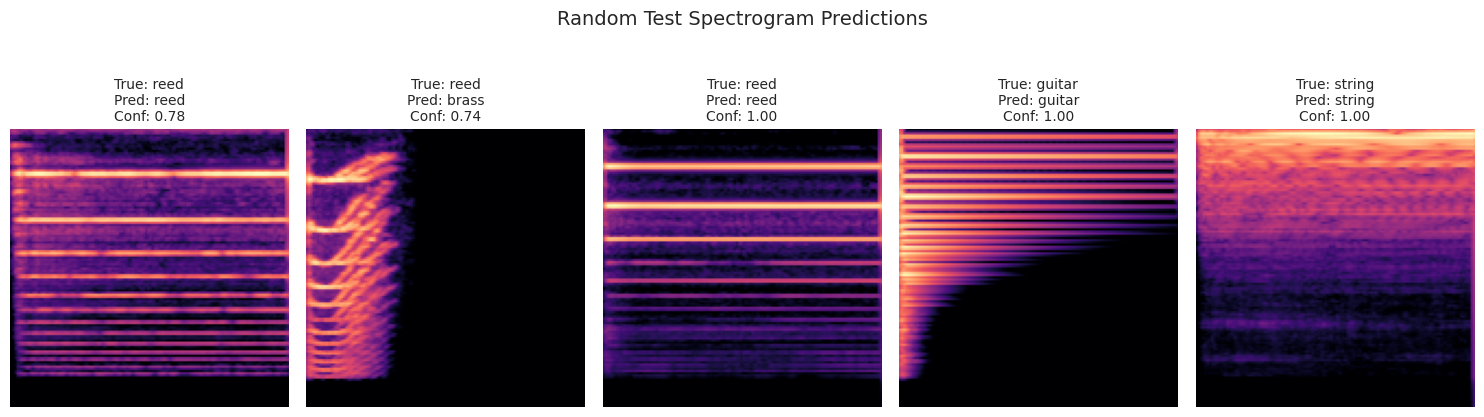

In [66]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))

for i, idx in enumerate(indices):
    spectrogram = X_test[idx]              # shape (128,128,1)
    true_label = y_test[idx]                # integer
    true_class = id_to_class[true_label]

    # Add batch dimension for prediction
    pred_probs = model.predict(
        spectrogram[np.newaxis, ...],
        verbose=0
    )
    pred_label = np.argmax(pred_probs)
    pred_class = id_to_class[pred_label]
    confidence = np.max(pred_probs)

    # Plot
    plt.subplot(1, NUM_SAMPLES, i + 1)
    plt.imshow(spectrogram.squeeze(), cmap="magma")
    plt.axis("off")
    plt.title(
        f"True: {true_class}\nPred: {pred_class}\nConf: {confidence:.2f}",
        fontsize=10
    )

plt.suptitle("Random Test Spectrogram Predictions", fontsize=14)
plt.tight_layout()
plt.show()
